# EDA notebook

The main objective of this notebook is to do a full exploratory data analysis and data audit.   
We are going to look into the main parts of the data such as:
- Missing data
- Structure of the data
- Make different plots
- Format of the data

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
data = pd.read_csv("../data/Digital_Payment_Fraud_Detection_Dataset.csv")
data.head()

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


In [28]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            7500 non-null   str    
 1   user_id                   7500 non-null   str    
 2   transaction_amount        7500 non-null   float64
 3   transaction_type          7500 non-null   str    
 4   payment_mode              7500 non-null   str    
 5   device_type               7500 non-null   str    
 6   device_location           7500 non-null   str    
 7   account_age_days          7500 non-null   int64  
 8   transaction_hour          7500 non-null   int64  
 9   previous_failed_attempts  7500 non-null   int64  
 10  avg_transaction_amount    7500 non-null   float64
 11  is_international          7500 non-null   int64  
 12  ip_risk_score             7500 non-null   float64
 13  login_attempts_last_24h   7500 non-null   int64  
 14  fraud_label        

From this code we can see there is no missing data and the data is correctly formatted

## Analysis of Traget feature

In [29]:
fraud_ratio = data['fraud_label'].mean()
print(f'The overall fraud ratio for this dataset is of {fraud_ratio * 100}%')

The overall fraud ratio for this dataset is of 6.52%


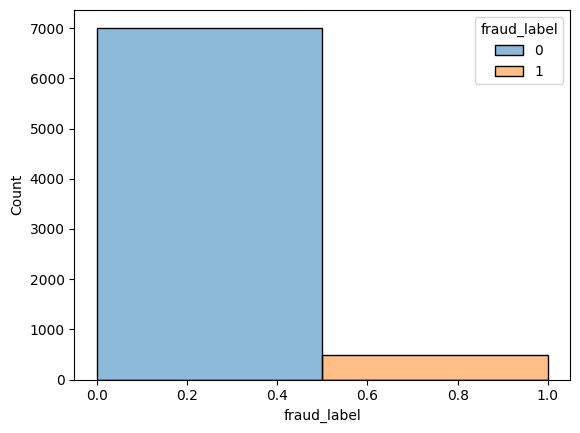

In [30]:
fraud_label = data['fraud_label']
sns.histplot(
    x=fraud_label,
    bins=2,
    hue=fraud_label
)
plt.show()

Here we can conclude that the dataset is very unbalanced. Following this we can try different thing, apply SMOTE or other oversamling techniques or apply class weights during the model training.

A good next step would be too dive deeper into the how it varies the fraud_rate depending on the the different categories

In [31]:
list_columns = ["is_international", "transaction_type", "payment_mode", 
                "device_type", "device_location", "login_attempts_last_24h",
                "previous_failed_attempts"]
for column in list_columns:
    fraud_ratio_column = data.groupby(column).agg({
        "fraud_label":["mean","count"]
    })
    print(column)
    display(fraud_ratio_column)
    print("-"*20)

is_international


fraud_label      
                        mean count
is_international                  
0                   0.066420  6745
1                   0.054305   755

--------------------
transaction_type


fraud_label      
                        mean count
transaction_type                  
Payment             0.063321  2511
Transfer            0.064257  2490
Withdrawal          0.068027  2499

--------------------
payment_mode


...

--------------------
login_attempts_last_24h


fraud_label      
                               mean count
login_attempts_last_24h                  
1                          0.056779   863
2                          0.063570   818
3                          0.057243   856
4                          0.063226   775
5                          0.066980   851
6                          0.071602   824
7                          0.073200   847
8                          0.067797   826
9                          0.066667   840

--------------------
previous_failed_attempts


fraud_label      
                                mean count
previous_failed_attempts                  
0                           0.057410  1498
1                           0.068687  1485
2                           0.060729  1482
3                           0.067922  1487
4                           0.071059  1548

--------------------


## User Count
We have seen that one of the variables is the user ID, so it would be interesting to see if there is more than only one row per user ID or there are multiple

In [32]:
user_fraud = data.groupby("user_id").agg({
    "fraud_label": ['count','mean']
}).reset_index()

print("Top 5 users with the most transactions:")
display(user_fraud.sort_values([('fraud_label','count')],ascending=False).head())
print("Top 5 users with the highest fraud rate:")
display(user_fraud.sort_values([('fraud_label','mean')],ascending=False).head())

Top 5 users with the most transactions:


user_id fraud_label     
                   count mean
146    U1247           6  0.0
3502   U7229           6  0.0
3259   U6797           6  0.0
4863   U9588           5  0.2
3865   U7845           5  0.0

Top 5 users with the highest fraud rate:


user_id fraud_label     
                   count mean
1512   U3769           1  1.0
1584   U3879           2  1.0
444    U1810           1  1.0
2611   U5688           1  1.0
1585   U3886           2  1.0

In [37]:
display(user_fraud[user_fraud[(('fraud_label','count'))]>1].sort_values([('fraud_label','mean'),('fraud_label','count')],ascending=False).head(15))

user_id fraud_label          
                   count      mean
1584   U3879           2  1.000000
1585   U3886           2  1.000000
2619   U5701           2  1.000000
461    U1840           3  0.666667
3702   U7573           3  0.666667
4758   U9402           3  0.666667
4871   U9606           4  0.500000
3      U1009           2  0.500000
42     U1073           2  0.500000
55     U1091           2  0.500000
76     U1132           2  0.500000
82     U1141           2  0.500000
92     U1157           2  0.500000
123    U1211           2  0.500000
160    U1270           2  0.500000

We can see that there are repetitions of users, so in this dataset users have made more than 1 transaction. So a possible feature engineering variable would be:
- Commited fraud before
- Amount of transactions made

**Then we can raise the question:**  
Are all the transactions in order?  
If that is the case we can genereta a new variable of commited fraude before. As there is no information in kaggle regarding this we are going to assume they are in order.


**How many users are there?**

In [50]:
users_unique = len(data.user_id.unique())
print(f"There are a total of {users_unique} users")

There are a total of 5106 users
